<a href="https://colab.research.google.com/github/joylouisa/Final-Project-1/blob/main/FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KONFIGURASI

In [ ]:
import os
from collections import Counter
import kagglehub

# Data & statistik
import pandas as pd
import numpy as np
import scipy as sc
from scipy.stats import chi2_contingency, kruskal

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, train_test_split

# Model
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# Resampling (imbalanced data)
from imblearn.over_sampling import SMOTENC, RandomOverSampler
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek

# Evaluasi
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    precision_recall_curve,
    average_precision_score
)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving DataSkripsi.xlsx to DataSkripsi (2).xlsx


In [ ]:
pd.read_excel('DataSkripsi.xlsx').to_csv("DataSkripsi.csv", index=False)
TARGET = "fraud_reported"
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

#  Muat data
df = pd.read_csv("DataSkripsi.csv")

In [ ]:
# Replace ? dengan NaN
df=df.replace('?',np.nan)

# Cek tipe data
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [ ]:
df.dtypes

,0
months_as_customer,int64
age,int64
policy_number,int64
policy_bind_date,object
policy_state,object
policy_csl,object
policy_deductable,int64
policy_annual_premium,float64
umbrella_limit,int64
insured_zip,int64


In [ ]:
df['fraud_reported'] = df['fraud_reported'].replace({'Y': 1, 'N': 0})

/tmp/ipykernel_564/840905909.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['fraud_reported'] = df['fraud_reported'].replace({'Y': 1, 'N': 0})


In [ ]:
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,2,YES,71610,6510,13020,52080,Saab,92x,2004,1
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,0,NaN,5070,780,780,3510,Mercedes,E400,2007,1
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,0
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,1
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,1,NO,6500,1300,650,4550,Accura,RSX,2009,0


# Split data

In [ ]:
X = df.drop(columns=['fraud_reported'])
y = df['fraud_reported']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train.to_csv(f"{OUTPUT_DIR}/X_train.csv", index=False)
X_test.to_csv(f"{OUTPUT_DIR}/X_test.csv", index=False)
y_train.to_csv(f"{OUTPUT_DIR}/y_train.csv", index=False)
y_test.to_csv(f"{OUTPUT_DIR}/y_test.csv", index=False)
print("Data split into training and testing sets. Shapes:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

Data split into training and testing sets. Shapes:
X_train: (800, 38)
X_test: (200, 38)
y_train: (800,)
y_test: (200,)


In [ ]:
print("=== Cek Jumlah Data Hasil Splitting ===")
print(f"Total data X      : {len(X_train) + len(X_test)}")
print(f"Total data y      : {len(y_train) + len(y_test)}\n")

print(f"X_train : {len(X_train)}")
print(f"X_test  : {len(X_test)}")

print(f"y_train : {len(y_train)}")
print(f"y_test  : {len(y_test)}")

=== Cek Jumlah Data Hasil Splitting ===
Total data X      : 1000
Total data y      : 1000

X_train : 800
X_test  : 200
y_train : 800
y_test  : 200


# EDA

In [ ]:
X_train.head(3)

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year
887,441,55,669501,2009-07-29,IN,250/500,500,1270.29,4000000,449421,...,0,0,NO,6400,640,640,5120,Honda,Civic,2002
317,275,45,403737,1991-12-06,IN,500/1000,2000,1447.77,0,605756,...,1,1,NaN,64320,5360,10720,48240,Accura,MDX,1998
796,421,56,728025,1990-02-15,IN,100/300,500,1935.85,4000000,470826,...,2,3,NaN,92730,16860,8430,67440,Mercedes,E400,2004


In [ ]:
X_train.tail(3)

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year
240,249,43,547802,2013-09-03,IL,250/500,1000,1518.46,0,606238,...,0,0,YES,53500,5350,5350,42800,Saab,92x,2015
263,244,40,226725,1999-08-11,IN,500/1000,2000,1304.67,7000000,605408,...,1,1,NaN,61490,5590,11180,44720,Dodge,RAM,2001
594,160,38,497929,2009-09-19,OH,250/500,500,1733.56,0,441425,...,2,1,YES,66780,7420,14840,44520,Mercedes,ML350,1996


In [ ]:
X_test.head(3)

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year
908,285,44,844117,1991-08-21,OH,250/500,2000,1144.30,0,609458,...,1,0,NaN,5500,500,500,4500,Honda,Civic,2010
973,230,37,776950,2005-04-11,IL,500/1000,1000,1060.74,0,471585,...,2,3,NaN,49100,9820,4910,34370,Suburu,Impreza,1996
154,101,33,575000,2012-06-23,OH,100/300,1000,1053.04,7000000,619540,...,1,3,NaN,54240,9040,9040,36160,Saab,93,2013


In [ ]:
X_test.tail(3)

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year
181,426,54,398102,1997-10-24,IL,500/1000,2000,1097.71,0,605258,...,2,3,NaN,100800,16800,16800,67200,Dodge,Neon,1997
421,147,37,525224,1992-10-02,IN,250/500,1000,1306.78,0,466818,...,1,0,NO,81120,13520,20280,47320,Toyota,Camry,1995
937,458,59,535879,2009-03-05,IN,100/300,1000,1685.69,0,472236,...,2,2,YES,71800,14360,14360,43080,Jeep,Grand Cherokee,1995


In [ ]:
# Cek tipe kolom kategorik dan numerik
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns

print(f"Banyak kolom numerik: {len(numerical_cols)}")
print(f"Banyak kolom kategorik: {len(categorical_cols)}")

# Print hasil
print("\nKolom numerik:")
print(list(numerical_cols))
print("\nKolom kategorik:")
print(list(categorical_cols))

Banyak kolom numerik: 19
Banyak kolom kategorik: 20

Kolom numerik:
['months_as_customer', 'age', 'policy_number', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year', 'fraud_reported']

Kolom kategorik:
['policy_bind_date', 'policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_date', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_location', 'property_damage', 'police_report_available', 'auto_make', 'auto_model']


In [ ]:
# Cek missing values
X_train.isna().sum()[df.isna().sum() > 0]

,0
collision_type,152
authorities_contacted,82
property_damage,286
police_report_available,268


In [ ]:
# Cek unique values di setiap kolom
for col in X_train.columns:
    print(f"Column '{col}': {X_train[col].nunique()} unique values")

Column 'months_as_customer': 360 unique values
Column 'age': 45 unique values
Column 'policy_number': 800 unique values
Column 'policy_bind_date': 763 unique values
Column 'policy_state': 3 unique values
Column 'policy_csl': 3 unique values
Column 'policy_deductable': 3 unique values
Column 'policy_annual_premium': 793 unique values
Column 'umbrella_limit': 11 unique values
Column 'insured_zip': 796 unique values
Column 'insured_sex': 2 unique values
Column 'insured_education_level': 7 unique values
Column 'insured_occupation': 14 unique values
Column 'insured_hobbies': 20 unique values
Column 'insured_relationship': 6 unique values
Column 'capital-gains': 285 unique values
Column 'capital-loss': 305 unique values
Column 'incident_date': 60 unique values
Column 'incident_type': 4 unique values
Column 'collision_type': 3 unique values
Column 'incident_severity': 4 unique values
Column 'authorities_contacted': 4 unique values
Column 'incident_state': 7 unique values
Column 'incident_city

In [ ]:
columns_to_drop = ['policy_number', 'policy_bind_date', "insured_zip", 'incident_date', 'incident_location', 'incident_city','auto_model']
X_train = X_train.drop(columns=columns_to_drop)
X_test = X_test.drop(columns=columns_to_drop)

In [ ]:
def print_outlier_details(X_train, threshold=1.5):
    numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

    print("=== DETAIL OUTLIER (IQR METHOD) ===\n")

    for col in numeric_cols:
        Q1 = X_train[col].quantile(0.25)
        Q3 = X_train[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - threshold * IQR
        upper = Q3 + threshold * IQR

        # baris yang outlier untuk kolom ini
        mask = (X_train[col] < lower) | (X_train[col] > upper)
        outlier_rows = X_train[mask]

        if not outlier_rows.empty:
            print(f"\n--- Kolom: {col} ---")
            print(f"   Batas bawah : {lower}")
            print(f"   Batas atas  : {upper}")
            print("   Outlier ditemukan pada:")

            for idx, value in outlier_rows[col].items():
                print(f"     • Baris {idx} | Nilai = {value}")

    print("\n=== SELESAI ===")
print_outlier_details(X_train)


=== DETAIL OUTLIER (IQR METHOD) ===


--- Kolom: age ---
   Batas bawah : 13.625
   Batas atas  : 62.625
   Outlier ditemukan pada:
     • Baris 588 | Nilai = 64
     • Baris 67 | Nilai = 64
     • Baris 947 | Nilai = 63
     • Baris 538 | Nilai = 63

--- Kolom: policy_annual_premium ---
   Batas bawah : 634.1299999999998
   Batas atas  : 1870.1100000000001
   Outlier ditemukan pada:
     • Baris 796 | Nilai = 1935.85
     • Baris 628 | Nilai = 625.08
     • Baris 229 | Nilai = 2047.59
     • Baris 544 | Nilai = 1927.87
     • Baris 133 | Nilai = 1922.84
     • Baris 747 | Nilai = 1969.63
     • Baris 379 | Nilai = 617.11
     • Baris 486 | Nilai = 1878.44
     • Baris 763 | Nilai = 484.67
     • Baris 43 | Nilai = 538.17
     • Baris 248 | Nilai = 433.33

--- Kolom: umbrella_limit ---
   Batas bawah : 0.0
   Batas atas  : 0.0
   Outlier ditemukan pada:
     • Baris 887 | Nilai = 4000000
     • Baris 796 | Nilai = 4000000
     • Baris 683 | Nilai = 4000000
     • Baris 86 | Nilai = 400

In [ ]:
col = X_train["age"]

Q1 = col.quantile(0.25)
Q3 = col.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower bound =", lower_bound)
print("Upper bound =", upper_bound)

# Tampilkan outlier (baris & nilai)
outliers = X_train[(col < lower_bound) | (col > upper_bound)]["age"]

for idx, val in outliers.items():
    print(f"Baris {idx} | Nilai = {val}")


Q1 = 32.0
Q3 = 44.25
IQR = 12.25
Lower bound = 13.625
Upper bound = 62.625
Baris 588 | Nilai = 64
Baris 67 | Nilai = 64
Baris 947 | Nilai = 63
Baris 538 | Nilai = 63


Distribusi kelas target:
                count  percentage
fraud_reported                   
0                 753        75.3
1                 247        24.7


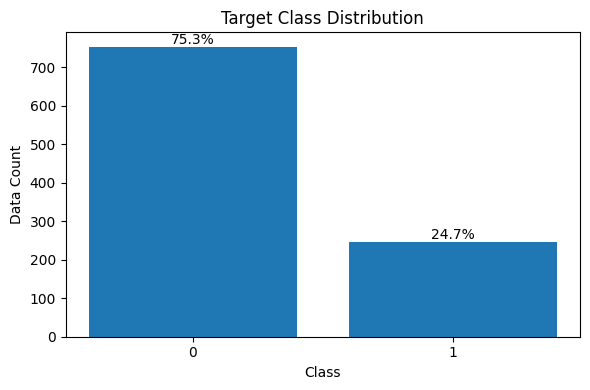

In [ ]:
# === Hitung distribusi kelas target ===
class_counts = df['fraud_reported'].value_counts()
class_percent = df['fraud_reported'].value_counts(normalize=True) * 100

# Gabungkan jadi tabel ringkas
imbalance_summary = pd.DataFrame({
    "count": class_counts,
    "percentage": class_percent.round(2)
})
imbalance_summary.to_csv("imbalanced_summary.csv")

print("Distribusi kelas target:")
print(imbalance_summary)

# === 3. Plot distribusi kelas ===
plt.figure(figsize=(6,4))
bars = plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Data Count")

# Tambahkan persentase di atas bar
for bar, pct in zip(bars, class_percent.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center", va="bottom"
    )

plt.tight_layout()
plt.savefig("imbalanced_plot.png")  # simpan chart ke file
plt.show()

# Data Preprocessing

Imputasi

In [ ]:
import pandas as pd

# Misal dataframe-mu bernama df
cols = ['collision_type', 'authorities_contacted', 'property_damage', 'police_report_available']

print("=== Modus Setiap Kolom ===")
for col in cols:
    # Pastikan kolomn 'col' ada di X_train sebelum mencoba mengaksesnya
    if col in X_train.columns:
        mode_value = X_train[col].mode(dropna=True)  # dropna=True supaya tidak memilih NaN sebagai modus
        if len(mode_value) > 0:
            print(f"{col}: {mode_value.iloc[0]}")
        else:
            print(f"{col}: (tidak ada nilai)")
    else:
        print(f"Kolom '{col}' tidak ditemukan di X_train.")

=== Modus Setiap Kolom ===
collision_type: Rear Collision
authorities_contacted: Police
property_damage: NO
police_report_available: NO


In [ ]:
cols = ['collision_type', 'authorities_contacted', 'property_damage', 'police_report_available']
categoric_missing = [col for col in cols if X_train[col].isnull().sum() > 0] # list kolom yang memiliki missing values

# imputer
mode_imputer = SimpleImputer(strategy='most_frequent')

# transformer
preprocessor = ColumnTransformer(
    transformers=[('mode_imputer', mode_imputer, categoric_missing)], # Corrected transformers argument
    remainder='passthrough'
    ).set_output(transform='pandas') # set output = pandas will convert numpy array into dataframe

preprocessor.fit(X_train)
X_train = preprocessor.transform(X_train)
X_test = preprocessor.transform(X_test)

print('Banyak missing values setelah imputasi: ',X_train.isnull().sum().sum())

Banyak missing values setelah imputasi:  0


In [ ]:
X_train.isnull().sum().sum()

np.int64(0)

In [ ]:
X_train.isnull().sum().sum()

np.int64(0)

**Encoding**

In [ ]:
# Identifikasi kolom kategorik
kolom_kategorik = X_train.select_dtypes(include=['object', 'category', 'bool']).columns

# One-Hot Encoding
X_train_encoded = pd.get_dummies(X_train, columns=kolom_kategorik, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=kolom_kategorik, drop_first=True)

In [ ]:
X_train_encoded.to_csv(f"{OUTPUT_DIR}/X_train_encoded.csv", index=False)
print(f"X_train_encoded saved to {OUTPUT_DIR}/X_train_encoded.csv")

X_train_encoded saved to output/X_train_encoded.csv


In [ ]:
X_train_encoded.head(5)

,remainder__months_as_customer,remainder__age,remainder__policy_deductable,remainder__policy_annual_premium,remainder__umbrella_limit,remainder__capital-gains,remainder__capital-loss,remainder__incident_hour_of_the_day,remainder__number_of_vehicles_involved,remainder__bodily_injuries,...,remainder__auto_make_Dodge,remainder__auto_make_Ford,remainder__auto_make_Honda,remainder__auto_make_Jeep,remainder__auto_make_Mercedes,remainder__auto_make_Nissan,remainder__auto_make_Saab,remainder__auto_make_Suburu,remainder__auto_make_Toyota,remainder__auto_make_Volkswagen
887,441,55,500,1270.29,4000000,24000,-50500,4,1,0,...,False,False,True,False,False,False,False,False,False,False
317,275,45,2000,1447.77,0,39400,-63900,8,3,1,...,False,False,False,False,False,False,False,False,False,False
796,421,56,500,1935.85,4000000,49500,-81100,7,1,2,...,False,False,False,False,True,False,False,False,False,False
425,4,34,500,1282.93,0,0,0,0,4,0,...,False,False,False,False,False,False,False,False,False,False
991,257,44,1000,1280.88,0,59400,-32200,21,1,0,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
X_train_encoded.tail(3)

,remainder__months_as_customer,remainder__age,remainder__policy_deductable,remainder__policy_annual_premium,remainder__umbrella_limit,remainder__capital-gains,remainder__capital-loss,remainder__incident_hour_of_the_day,remainder__number_of_vehicles_involved,remainder__bodily_injuries,...,remainder__auto_make_Dodge,remainder__auto_make_Ford,remainder__auto_make_Honda,remainder__auto_make_Jeep,remainder__auto_make_Mercedes,remainder__auto_make_Nissan,remainder__auto_make_Saab,remainder__auto_make_Suburu,remainder__auto_make_Toyota,remainder__auto_make_Volkswagen
240,249,43,1000,1518.46,0,0,0,16,1,0,...,False,False,False,False,False,False,True,False,False,False
263,244,40,2000,1304.67,7000000,0,-45000,5,3,1,...,True,False,False,False,False,False,False,False,False,False
594,160,38,500,1733.56,0,0,-43800,13,3,2,...,False,False,False,False,True,False,False,False,False,False


In [ ]:
X_test_encoded.head(3)

,remainder__months_as_customer,remainder__age,remainder__policy_deductable,remainder__policy_annual_premium,remainder__umbrella_limit,remainder__capital-gains,remainder__capital-loss,remainder__incident_hour_of_the_day,remainder__number_of_vehicles_involved,remainder__bodily_injuries,...,remainder__auto_make_Dodge,remainder__auto_make_Ford,remainder__auto_make_Honda,remainder__auto_make_Jeep,remainder__auto_make_Mercedes,remainder__auto_make_Nissan,remainder__auto_make_Saab,remainder__auto_make_Suburu,remainder__auto_make_Toyota,remainder__auto_make_Volkswagen
908,285,44,2000,1144.30,0,52600,0,3,1,1,...,False,False,True,False,False,False,False,False,False,False
973,230,37,1000,1060.74,0,0,-51500,15,1,2,...,False,False,False,False,False,False,False,True,False,False
154,101,33,1000,1053.04,7000000,52000,-44500,20,3,1,...,False,False,False,False,False,False,True,False,False,False


In [ ]:
X_test_encoded.tail(3)

,remainder__months_as_customer,remainder__age,remainder__policy_deductable,remainder__policy_annual_premium,remainder__umbrella_limit,remainder__capital-gains,remainder__capital-loss,remainder__incident_hour_of_the_day,remainder__number_of_vehicles_involved,remainder__bodily_injuries,...,remainder__auto_make_Dodge,remainder__auto_make_Ford,remainder__auto_make_Honda,remainder__auto_make_Jeep,remainder__auto_make_Mercedes,remainder__auto_make_Nissan,remainder__auto_make_Saab,remainder__auto_make_Suburu,remainder__auto_make_Toyota,remainder__auto_make_Volkswagen
181,426,54,2000,1097.71,0,29600,-22300,13,1,2,...,True,False,False,False,False,False,False,False,False,False
421,147,37,1000,1306.78,0,0,0,22,1,1,...,False,False,False,False,False,False,False,False,True,False
937,458,59,1000,1685.69,0,31400,0,23,1,2,...,False,False,False,True,False,False,False,False,False,False


In [ ]:
# === 5. Normalisasi ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_encoded.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test_encoded.columns)
X_train_scaled_df.to_csv(f"{OUTPUT_DIR}/X_train_normalized.csv", index=False)
X_test_scaled_df.to_csv(f"{OUTPUT_DIR}/X_test_normalized.csv", index=False)

print("Hasil Normalisasi Data X_train")
display(X_train_scaled_df.head(3))

Hasil Normalisasi Data X_train


,remainder__months_as_customer,remainder__age,remainder__policy_deductable,remainder__policy_annual_premium,remainder__umbrella_limit,remainder__capital-gains,remainder__capital-loss,remainder__incident_hour_of_the_day,remainder__number_of_vehicles_involved,remainder__bodily_injuries,...,remainder__auto_make_Dodge,remainder__auto_make_Ford,remainder__auto_make_Honda,remainder__auto_make_Jeep,remainder__auto_make_Mercedes,remainder__auto_make_Nissan,remainder__auto_make_Saab,remainder__auto_make_Suburu,remainder__auto_make_Toyota,remainder__auto_make_Volkswagen
0,2.074615,1.755386,-1.041729,0.050053,1.295503,-0.019577,-0.859126,-1.096975,-0.821792,-1.202225,...,-0.276977,-0.282174,4.145096,-0.266365,-0.266365,-0.274352,-0.299864,-0.309662,-0.266365,-0.274352
1,0.621501,0.657154,1.378552,0.784755,-0.477641,0.537069,-1.338801,-0.517236,1.140697,0.006041,...,-0.276977,-0.282174,-0.241249,-0.266365,-0.266365,-0.274352,-0.299864,-0.309662,-0.266365,-0.274352
2,1.899541,1.865209,-1.041729,2.805228,1.295503,0.902142,-1.954505,-0.662171,-0.821792,1.214308,...,-0.276977,-0.282174,-0.241249,-0.266365,3.754243,-0.274352,-0.299864,-0.309662,-0.266365,-0.274352


In [ ]:
X_train_scaled_df.to_csv(f"{OUTPUT_DIR}/X_train_scaled_df.csv", index=False)
print(f"X_train_scaled_df saved to {OUTPUT_DIR}/X_train_scaled_df.csv")

X_train_scaled_df saved to output/X_train_scaled_df.csv


In [ ]:
print("Hasil Normalisasi Data X_train")
display(X_train_scaled_df.tail(3))

Hasil Normalisasi Data X_train


,remainder__months_as_customer,remainder__age,remainder__policy_deductable,remainder__policy_annual_premium,remainder__umbrella_limit,remainder__capital-gains,remainder__capital-loss,remainder__incident_hour_of_the_day,remainder__number_of_vehicles_involved,remainder__bodily_injuries,...,remainder__auto_make_Dodge,remainder__auto_make_Ford,remainder__auto_make_Honda,remainder__auto_make_Jeep,remainder__auto_make_Mercedes,remainder__auto_make_Nissan,remainder__auto_make_Saab,remainder__auto_make_Suburu,remainder__auto_make_Toyota,remainder__auto_make_Volkswagen
797,0.393905,0.437508,-0.234969,1.077386,-0.477641,-0.887078,0.948608,0.642242,-0.821792,-1.202225,...,-0.276977,-0.282174,-0.241249,-0.266365,-0.266365,-0.274352,3.334848,-0.309662,-0.266365,-0.274352
798,0.350137,0.108039,1.378552,0.192373,2.625361,-0.887078,-0.662244,-0.952040,1.140697,0.006041,...,3.610414,-0.282174,-0.241249,-0.266365,-0.266365,-0.274352,-0.299864,-0.309662,-0.266365,-0.274352
799,-0.385173,-0.111608,-1.041729,1.967821,-0.477641,-0.887078,-0.619288,0.207438,1.140697,1.214308,...,-0.276977,-0.282174,-0.241249,-0.266365,3.754243,-0.274352,-0.299864,-0.309662,-0.266365,-0.274352


In [ ]:
print("Hasil Normalisasi Data X_test")
display(X_test_scaled_df.head(3))

Hasil Normalisasi Data X_test


,remainder__months_as_customer,remainder__age,remainder__policy_deductable,remainder__policy_annual_premium,remainder__umbrella_limit,remainder__capital-gains,remainder__capital-loss,remainder__incident_hour_of_the_day,remainder__number_of_vehicles_involved,remainder__bodily_injuries,...,remainder__auto_make_Dodge,remainder__auto_make_Ford,remainder__auto_make_Honda,remainder__auto_make_Jeep,remainder__auto_make_Mercedes,remainder__auto_make_Nissan,remainder__auto_make_Saab,remainder__auto_make_Suburu,remainder__auto_make_Toyota,remainder__auto_make_Volkswagen
0,0.709038,0.547331,1.378552,-0.471500,-0.477641,1.014194,0.948608,-1.241909,-0.821792,0.006041,...,-0.276977,-0.282174,4.145096,-0.266365,-0.266365,-0.274352,-0.299864,-0.309662,-0.266365,-0.274352
1,0.227585,-0.221431,-0.234969,-0.817408,-0.477641,-0.887078,-0.894922,0.497307,-0.821792,1.214308,...,-0.276977,-0.282174,-0.241249,-0.266365,-0.266365,-0.274352,-0.299864,3.229330,-0.266365,-0.274352
2,-0.901641,-0.660724,-0.234969,-0.849283,2.625361,0.992506,-0.644345,1.221981,1.140697,0.006041,...,-0.276977,-0.282174,-0.241249,-0.266365,-0.266365,-0.274352,3.334848,-0.309662,-0.266365,-0.274352


In [ ]:
print("Hasil Normalisasi Data X_test")
display(X_test_scaled_df.tail(3))

Hasil Normalisasi Data X_test


,remainder__months_as_customer,remainder__age,remainder__policy_deductable,remainder__policy_annual_premium,remainder__umbrella_limit,remainder__capital-gains,remainder__capital-loss,remainder__incident_hour_of_the_day,remainder__number_of_vehicles_involved,remainder__bodily_injuries,...,remainder__auto_make_Dodge,remainder__auto_make_Ford,remainder__auto_make_Honda,remainder__auto_make_Jeep,remainder__auto_make_Mercedes,remainder__auto_make_Nissan,remainder__auto_make_Saab,remainder__auto_make_Suburu,remainder__auto_make_Toyota,remainder__auto_make_Volkswagen
197,1.943309,1.645563,1.378552,-0.664365,-0.477641,0.182839,0.150342,0.207438,-0.821792,1.214308,...,3.610414,-0.282174,-0.241249,-0.266365,-0.266365,-0.274352,-0.299864,-0.309662,-0.266365,-0.274352
198,-0.498971,-0.221431,-0.234969,0.201108,-0.477641,-0.887078,0.948608,1.511850,-0.821792,0.006041,...,-0.276977,-0.282174,-0.241249,-0.266365,-0.266365,-0.274352,-0.299864,-0.309662,3.754243,-0.274352
199,2.223427,2.194679,-0.234969,1.769657,-0.477641,0.247902,0.948608,1.656785,-0.821792,1.214308,...,-0.276977,-0.282174,-0.241249,3.754243,-0.266365,-0.274352,-0.299864,-0.309662,-0.266365,-0.274352


In [ ]:
# Seleksi fitur dengan Mutual Information

from sklearn.feature_selection import mutual_info_classif

# Menghitung skor mutual information
mutual_info = mutual_info_classif(X_train_scaled_df, y_train, random_state=42)
mutual_info = pd.Series(mutual_info, index=X_train_scaled_df.columns)
mutual_info.sort_values(ascending=False, inplace=True)

print("Mutual Information Scores:")
display(mutual_info)

Mutual Information Scores:


,0
remainder__insured_hobbies_chess,0.052563
remainder__insured_hobbies_camping,0.032673
remainder__property_claim,0.032323
remainder__total_claim_amount,0.029101
remainder__insured_hobbies_kayaking,0.025511
...,...
remainder__auto_make_Audi,0.000000
remainder__auto_make_Nissan,0.000000
remainder__auto_make_Jeep,0.000000
remainder__auto_make_Toyota,0.000000


In [ ]:
# Identifikasi kolom dengan score mutual information = 0
cols_to_drop_mi = mutual_info[mutual_info == 0].index.tolist()
print(f"Kolom yang didrop: {cols_to_drop_mi}")

Kolom yang didrop: ['mode_imputer__collision_type_Rear Collision', 'mode_imputer__authorities_contacted_Police', 'mode_imputer__police_report_available_YES', 'remainder__incident_hour_of_the_day', 'remainder__capital-loss', 'remainder__capital-gains', 'remainder__umbrella_limit', 'remainder__policy_deductable', 'remainder__age', 'remainder__months_as_customer', 'remainder__auto_year', 'remainder__insured_education_level_MD', 'remainder__insured_education_level_JD', 'remainder__policy_csl_250/500', 'remainder__policy_csl_500/1000', 'remainder__policy_state_OH', 'remainder__insured_hobbies_movies', 'remainder__insured_hobbies_polo', 'remainder__insured_hobbies_paintball', 'remainder__insured_education_level_Masters', 'remainder__insured_occupation_machine-op-inspct', 'remainder__insured_education_level_PhD', 'remainder__insured_occupation_craft-repair', 'remainder__insured_occupation_farming-fishing', 'remainder__insured_hobbies_exercise', 'remainder__insured_occupation_priv-house-serv',

In [ ]:
# Drop kolom
X_train_scaled_df.drop(columns=cols_to_drop_mi, inplace=True)
X_test_scaled_df.drop(columns=cols_to_drop_mi, inplace=True)

print(f"Kolom yang didrop: {cols_to_drop_mi}")
print("\nKolom X_train_scaled_df baru:")
print(X_train_scaled_df.columns)
print("\nKolom X_test_scaled_df baru:")
print(X_test_scaled_df.columns)

Kolom yang didrop: ['mode_imputer__collision_type_Rear Collision', 'mode_imputer__authorities_contacted_Police', 'mode_imputer__police_report_available_YES', 'remainder__incident_hour_of_the_day', 'remainder__capital-loss', 'remainder__capital-gains', 'remainder__umbrella_limit', 'remainder__policy_deductable', 'remainder__age', 'remainder__months_as_customer', 'remainder__auto_year', 'remainder__insured_education_level_MD', 'remainder__insured_education_level_JD', 'remainder__policy_csl_250/500', 'remainder__policy_csl_500/1000', 'remainder__policy_state_OH', 'remainder__insured_hobbies_movies', 'remainder__insured_hobbies_polo', 'remainder__insured_hobbies_paintball', 'remainder__insured_education_level_Masters', 'remainder__insured_occupation_machine-op-inspct', 'remainder__insured_education_level_PhD', 'remainder__insured_occupation_craft-repair', 'remainder__insured_occupation_farming-fishing', 'remainder__insured_hobbies_exercise', 'remainder__insured_occupation_priv-house-serv',

In [ ]:
print(f"Number of features left: {X_train_scaled_df.shape[1]}")

Number of features left: 53


In [ ]:
X_train_scaled_df.to_csv(f"{OUTPUT_DIR}/X_train_scaled_df.csv", index=False)
print(f"X_train_scaled_df saved to {OUTPUT_DIR}/X_train_scaled_df.csv")

X_train_scaled_df saved to output/X_train_scaled_df.csv


In [ ]:
# === 6. Cek imbalance ===
y_train.value_counts().to_csv(f"{OUTPUT_DIR}/class_distribution.csv")

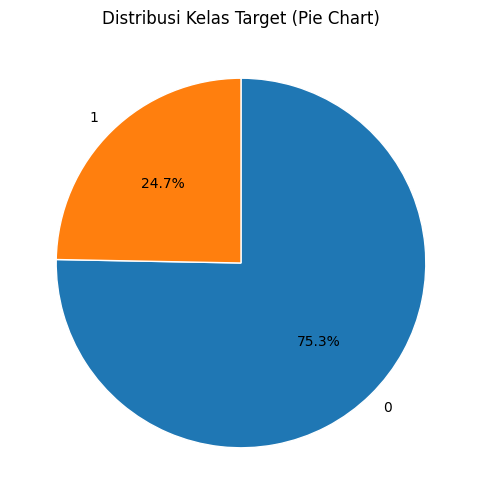

Distribusi kelas target:
                count  percentage
fraud_reported                   
0                 753        75.3
1                 247        24.7


In [ ]:
#pie chart
plt.figure(figsize=(6,6))
plt.pie(class_counts.values,
        labels=class_counts.index.astype(str),
        autopct='%1.1f%%',
        startangle=90,
        counterclock=False,
        wedgeprops={'edgecolor': 'white'})

plt.title("Distribusi Kelas Target (Pie Chart)")
plt.savefig("imbalanced_pie.png")
plt.show()

# === 4. Simpan ringkasan ke CSV ===
imbalance_summary = pd.DataFrame({
    "count": class_counts,
    "percentage": class_percent.round(2)
})
imbalance_summary.to_csv("imbalanced_summary.csv")

print("Distribusi kelas target:")
print(imbalance_summary)

In [ ]:
y_train.to_csv(f"{OUTPUT_DIR}/y_train.csv", index=False)
print(f"y_train saved to {OUTPUT_DIR}/y_train.csv")

y_train saved to output/y_train.csv


# TANPA PENANGANAN *IMBALANCED CLASS*

Melatih Bagging Classifier...
Prediksi ke data test...
Hasil disimpan di: output/bagging_no_resampling_test_results.csv

Hasil evaluasi:
                     Model  n_estimators  Accuracy  Precision   Recall  F1-Score
Bagging (Tanpa Resampling)            50     0.805   0.604167 0.591837  0.597938

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       151
           1       0.60      0.59      0.60        49

    accuracy                           0.81       200
   macro avg       0.74      0.73      0.73       200
weighted avg       0.80      0.81      0.80       200


Confusion matrix:
[[132  19]
 [ 20  29]]


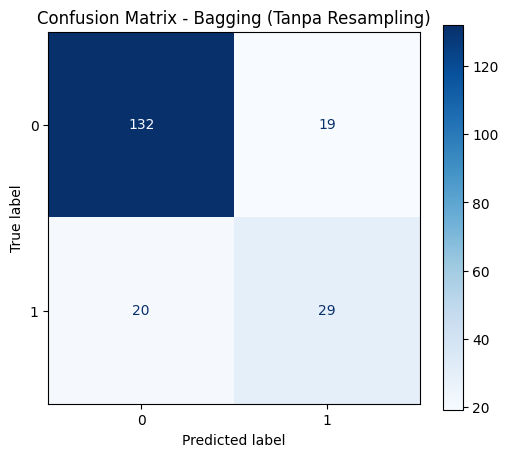

In [ ]:
# Data
X_train = X_train_scaled_df
X_test = X_test_scaled_df

print("Melatih Bagging Classifier...")
model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Prediksi
print("Prediksi ke data test...")
y_pred = model.predict(X_test)

# Evaluasi
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

results_df = pd.DataFrame([{
    "Model": "Bagging (Tanpa Resampling)",
    "n_estimators": 50,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
}])

# Simpan hasil
output_path = f"{OUTPUT_DIR}/bagging_no_resampling_test_results.csv"
results_df.to_csv(output_path, index=False)
print(f"Hasil disimpan di: {output_path}")

print("\nHasil evaluasi:")
print(results_df.to_string(index=False))

print("\nClassification report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title("Confusion Matrix - Bagging (Tanpa Resampling)")
plt.show()

# DENGAN PENANGANAN *IMBALANCED CLASS*

# SMOTE-NC + TOMEK LINKS

Jumlah kolom      : 53
Kolom numerik     : 5
Index kategorik   : [2, 3, 5, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]

Resampling dengan SMOTE-NC + Tomek Links
Distribusi awal  : {0: 602, 1: 198}
Distribusi akhir : {0: 602, 1: 575}

Training Bagging...
Training selesai

Evaluasi ke data test
Accuracy  : 0.8100
Precision : 0.6279
Recall    : 0.5510
F1-Score  : 0.5870

Classification report:
              precision    recall  f1-score   support

           0       0.86      0.89      0.88       151
           1       0.63      0.55      0.59        49

    accuracy                           0.81       200
   macro avg       0.74      0.72      0.73       200
weighted avg       0.80      0.81      0.81       200


Confusion matrix:
[[135  16]
 [ 22  27]]


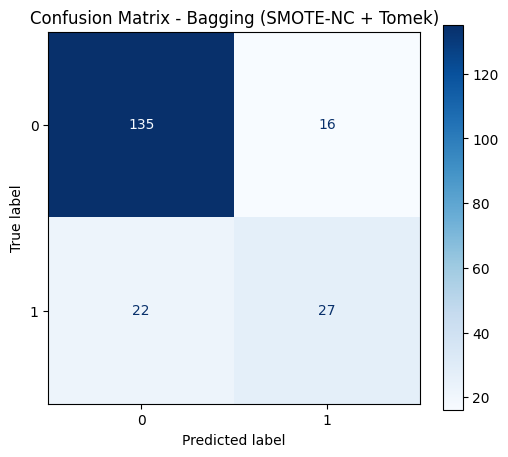

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTENC
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import TomekLinks

# Persiapan data
X = X_train_scaled_df.reset_index(drop=True)
y = y_train.reset_index(drop=True)

num_cols_ref = [
    'remainder__age',
    'remainder__policy_deductable',
    'remainder__policy_annual_premium',
    'remainder__capital-gains',
    'remainder__capital-loss',
    'remainder__incident_hour_of_the_day',
    'remainder__number_of_vehicles_involved',
    'remainder__total_claim_amount',
    'remainder__property_claim',
    'remainder__vehicle_claim',
    'remainder__auto_year'
]

real_num_cols = [c for c in X.columns if c in num_cols_ref]
real_cat_cols = [c for c in X.columns if c not in num_cols_ref]

categorical_indices = [X.columns.get_loc(c) for c in real_cat_cols]

print(f"Jumlah kolom      : {len(X.columns)}")
print(f"Kolom numerik     : {len(real_num_cols)}")
print(f"Index kategorik   : {categorical_indices}")

if len(real_num_cols) == 0:
    raise ValueError("Tidak ada kolom numerik terdeteksi")

# Resampling
print("\nResampling dengan SMOTE-NC + Tomek Links")

min_samples = y.value_counts().min()
k_neighbors = 5 if min_samples > 5 else (min_samples - 1 if min_samples > 1 else 1)

try:
    print(f"Distribusi awal  : {dict(Counter(y))}")

    resampler = SMOTETomek(
        smote=SMOTENC(
            categorical_features=categorical_indices,
            sampling_strategy='auto',
            k_neighbors=k_neighbors,
            random_state=42
        ),
        tomek=TomekLinks(sampling_strategy='auto'),
        random_state=42
    )

    X_train_final, y_train_final = resampler.fit_resample(X, y)
    print(f"Distribusi akhir : {dict(Counter(y_train_final))}")

except Exception as e:
    print(f"Resampling gagal: {e}")
    X_train_final, y_train_final = X, y

# Training model
print("\nTraining Bagging...")
model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_final, y_train_final)
print("Training selesai")

# Evaluasi
print("\nEvaluasi ke data test")
y_test_eval = y_test
y_pred = model.predict(X_test_scaled_df)

accuracy_smotenc_tl = accuracy_score(y_test_eval, y_pred)
precision_smotenc_tl = precision_score(y_test_eval, y_pred, zero_division=0)
recall_smotenc_tl = recall_score(y_test_eval, y_pred, zero_division=0)
f1_smotenc_tl = f1_score(y_test_eval, y_pred, zero_division=0)

print(f"Accuracy  : {accuracy_smotenc_tl:.4f}")
print(f"Precision : {precision_smotenc_tl:.4f}")
print(f"Recall    : {recall_smotenc_tl:.4f}")
print(f"F1-Score  : {f1_smotenc_tl:.4f}")

print("\nClassification report:")
print(classification_report(y_test_eval, y_pred))

print("\nConfusion matrix:")
cm = confusion_matrix(y_test_eval, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title("Confusion Matrix - Bagging (SMOTE-NC + Tomek)")
plt.show()

# ROS + TOMEK LINKS

Distribusi kelas setelah ROS:
Counter({0: 602, 1: 602})
Distribusi kelas setelah ROS + Tomek Links:
Counter({0: 602, 1: 593})
Melatih Bagging Classifier...
Melakukan prediksi ke data test...
Hasil disimpan di: output/bagging_ros_tl_test_results.csv

Hasil evaluasi:
                      Model  n_estimators  Accuracy  Precision   Recall  F1-Score
Bagging (ROS + Tomek Links)            50     0.805   0.604167 0.591837  0.597938

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       151
           1       0.67      0.71      0.69        49

    accuracy                           0.84       200
   macro avg       0.79      0.80      0.79       200
weighted avg       0.85      0.84      0.85       200


Confusion matrix:
[[134  17]
 [ 14  35]]


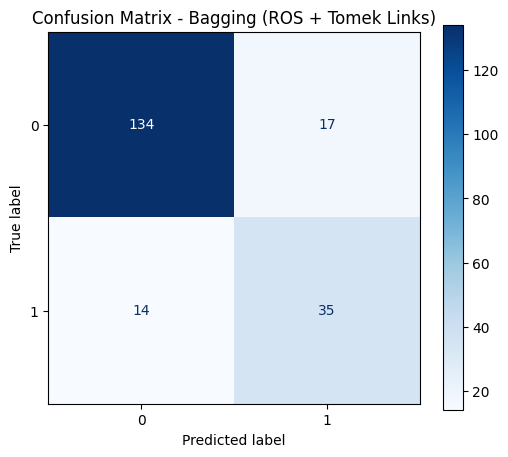

In [ ]:
# Resampling: ROS + Tomek Links
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train_scaled_df, y_train)

print("Distribusi kelas setelah ROS:")
print(Counter(y_ros))

tl = TomekLinks(sampling_strategy='auto', n_jobs=-1)
X_resampled, y_resampled = tl.fit_resample(X_ros, y_ros)

print("Distribusi kelas setelah ROS + Tomek Links:")
print(Counter(y_resampled))

# Training model
X_train_final = X_resampled
y_train_final = y_resampled
X_test_eval = X_test_scaled_df
y_test_eval = y_test

print("Melatih Bagging Classifier...")

bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

bag_model.fit(X_train_final, y_train_final)

# Prediksi
print("Melakukan prediksi ke data test...")
y_pred = bag_model.predict(X_test_eval)

# Evaluasi
ros_tl_accuracy = accuracy_score(y_test_eval, y_pred)
ros_tl_precision = precision_score(y_test_eval, y_pred, zero_division=0)
ros_tl_recall = recall_score(y_test_eval, y_pred, zero_division=0)
ros_tl_f1 = f1_score(y_test_eval, y_pred, zero_division=0)

ros_results_df = pd.DataFrame([{
    "Model": "Bagging (ROS + Tomek Links)",
    "n_estimators": 50,
    "Accuracy": ros_tl_accuracy,
    "Precision": ros_tl_precision,
    "Recall": ros_tl_recall,
    "F1-Score": ros_tl_f1
}])

# Simpan hasil
output_path = f"{OUTPUT_DIR}/bagging_ros_tl_test_results.csv"
results_df.to_csv(output_path, index=False)
print(f"Hasil disimpan di: {output_path}")

print("\nHasil evaluasi:")
print(results_df.to_string(index=False))

print("\nClassification report:")
print(classification_report(y_test_eval, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test_eval, y_pred)
print("\nConfusion matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=bag_model.classes_)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title("Confusion Matrix - Bagging (ROS + Tomek Links)")
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_ros_tl.png")
plt.show()

In [ ]:
ros_tl_accuracy = ros_results_df['Accuracy'].iloc[0]
ros_tl_precision = ros_results_df['Precision'].iloc[0]
ros_tl_recall = ros_results_df['Recall'].iloc[0]
ros_tl_f1 = ros_results_df['F1-Score'].iloc[0]

print(f"ROS + Tomek Links Accuracy: {ros_tl_accuracy:.4f}")
print(f"ROS + Tomek Links Precision (Class 1): {ros_tl_precision:.4f}")
print(f"ROS + Tomek Links Recall (Class 1): {ros_tl_recall:.4f}")
print(f"ROS + Tomek Links F1-Score (Class 1): {ros_tl_f1:.4f}")

ROS + Tomek Links Accuracy: 0.8450
ROS + Tomek Links Precision (Class 1): 0.6731
ROS + Tomek Links Recall (Class 1): 0.7143
ROS + Tomek Links F1-Score (Class 1): 0.6931


# Tomek Links + SMOTE-NC

Mulai training pipeline
Jumlah kolom     : 53
Index kategorik  : [2, 3, 5, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]
Distribusi awal  : {0: 602, 1: 198}

Tomek Links...
Setelah cleaning : {0: 559, 1: 198}
SMOTE-NC...
Distribusi akhir : {0: 559, 1: 559}

Training Bagging...
Training selesai

Prediksi ke data test...

Accuracy  : 0.8200
Precision : 0.6327
Recall    : 0.6327
F1-Score  : 0.6327

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       151
           1       0.63      0.63      0.63        49

    accuracy                           0.82       200
   macro avg       0.76      0.76      0.76       200
weighted avg       0.82      0.82      0.82       200


Confusion matrix:
[[133  18]
 [ 18  31]]


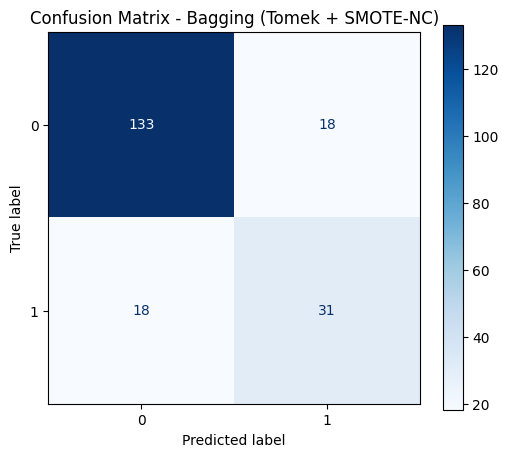

In [ ]:
from imblearn.over_sampling import SMOTENC
from imblearn.under_sampling import TomekLinks

# Persiapan data
X = X_train_scaled_df.reset_index(drop=True)
y = y_train.reset_index(drop=True)
y_test_eval = y_test

# Kolom numerik
num_cols_ref = [
    'remainder__age',
    'remainder__policy_deductable',
    'remainder__policy_annual_premium',
    'remainder__capital-gains',
    'remainder__capital-loss',
    'remainder__incident_hour_of_the_day',
    'remainder__number_of_vehicles_involved',
    'remainder__total_claim_amount',
    'remainder__property_claim',
    'remainder__vehicle_claim',
    'remainder__auto_year'
]

real_num_cols = [c for c in X.columns if c in num_cols_ref]
real_cat_cols = [c for c in X.columns if c not in num_cols_ref]

categorical_indices = [X.columns.get_loc(c) for c in real_cat_cols]

print("Mulai training pipeline")
print(f"Jumlah kolom     : {len(X.columns)}")
print(f"Index kategorik  : {categorical_indices}")
print(f"Distribusi awal  : {dict(Counter(y))}")

if len(real_num_cols) == 0:
    raise ValueError("Tidak ada kolom numerik terdeteksi")

# Resampling
print("\nTomek Links...")
tl = TomekLinks(sampling_strategy='auto')
X_clean, y_clean = tl.fit_resample(X, y)
print(f"Setelah cleaning : {dict(Counter(y_clean))}")

print("SMOTE-NC...")
min_samples = y_clean.value_counts().min()
k_neighbors = 5 if min_samples > 5 else (min_samples - 1 if min_samples > 1 else 1)

smote_nc = SMOTENC(
    categorical_features=categorical_indices,
    sampling_strategy='auto',
    k_neighbors=k_neighbors,
    random_state=42
)

X_train_final, y_train_final = smote_nc.fit_resample(X_clean, y_clean)
print(f"Distribusi akhir : {dict(Counter(y_train_final))}")

# Training model
print("\nTraining Bagging...")
model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_final, y_train_final)
print("Training selesai")

# Prediksi
print("\nPrediksi ke data test...")
y_pred = model.predict(X_test_scaled_df)

# Evaluasi
accuracy_tl_smotenc = accuracy_score(y_test_eval, y_pred)
precision_tl_smotenc = precision_score(y_test_eval, y_pred, zero_division=0)
recall_tl_smotenc = recall_score(y_test_eval, y_pred, zero_division=0)
f1_tl_smotenc = f1_score(y_test_eval, y_pred, zero_division=0)

print(f"\nAccuracy  : {accuracy_tl_smotenc:.4f}")
print(f"Precision : {precision_tl_smotenc:.4f}")
print(f"Recall    : {recall_tl_smotenc:.4f}")
print(f"F1-Score  : {f1_tl_smotenc:.4f}")

print("\nClassification report:")
print(classification_report(y_test_eval, y_pred))

print("\nConfusion matrix:")
cm = confusion_matrix(y_test_eval, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title("Confusion Matrix - Bagging (Tomek + SMOTE-NC)")
plt.show()

# Tomek Links + ROS

Mulai training pipeline
Distribusi awal: {0: 602, 1: 198}

Tomek Links...
Setelah cleaning: {0: 559, 1: 198}
Random Over Sampling...
Distribusi akhir: {0: 559, 1: 559}

Training Bagging...
Training selesai

Prediksi ke data test...

Accuracy  : 0.8350
Precision : 0.6538
Recall    : 0.6939
F1-Score  : 0.6733

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       151
           1       0.65      0.69      0.67        49

    accuracy                           0.83       200
   macro avg       0.78      0.79      0.78       200
weighted avg       0.84      0.83      0.84       200


Confusion matrix:
[[133  18]
 [ 15  34]]


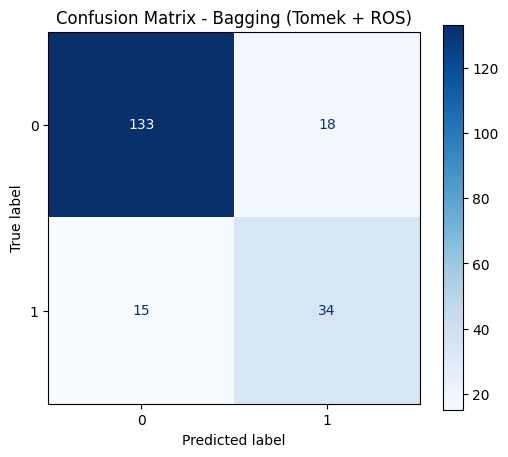

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import TomekLinks
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Persiapan data
X = X_train_scaled_df.reset_index(drop=True)
y = y_train.reset_index(drop=True)
y_test_eval = y_test

print("Mulai training pipeline")
print(f"Distribusi awal: {dict(Counter(y))}")

# Resampling
print("\nTomek Links...")
tomek = TomekLinks(sampling_strategy='auto')
X_clean, y_clean = tomek.fit_resample(X, y)
print(f"Setelah cleaning: {dict(Counter(y_clean))}")

print("Random Over Sampling...")
ros = RandomOverSampler(sampling_strategy='auto', random_state=42)
X_train_final, y_train_final = ros.fit_resample(X_clean, y_clean)
print(f"Distribusi akhir: {dict(Counter(y_train_final))}")

# Training model
print("\nTraining Bagging...")
model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_final, y_train_final)
print("Training selesai")

# Prediksi
print("\nPrediksi ke data test...")
y_pred = model.predict(X_test_scaled_df)

# Evaluasi
accuracy_tl_ros = accuracy_score(y_test_eval, y_pred)
precision_tl_ros = precision_score(y_test_eval, y_pred, zero_division=0)
recall_tl_ros = recall_score(y_test_eval, y_pred, zero_division=0)
f1_tl_ros = f1_score(y_test_eval, y_pred, zero_division=0)

print(f"\nAccuracy  : {accuracy_tl_ros:.4f}")
print(f"Precision : {precision_tl_ros:.4f}")
print(f"Recall    : {recall_tl_ros:.4f}")
print(f"F1-Score  : {f1_tl_ros:.4f}")

print("\nClassification report:")
print(classification_report(y_test_eval, y_pred))

print("\nConfusion matrix:")
cm = confusion_matrix(y_test_eval, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title("Confusion Matrix - Bagging (Tomek + ROS)")
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_ros_tl.png")
plt.show()

# Perbandingan

In [ ]:
import pandas as pd

# Menggabungkan hasil ke dalam list
results_data = [
    {
        "Strategi Model": "Baseline (Tanpa Resampling)",
        "Akurasi": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    },
    {
        "Strategi Model": "SMOTE-NC + Tomek Links",
        "Akurasi": accuracy_smotenc_tl,
        "Precision": precision_smotenc_tl,
        "Recall": recall_smotenc_tl,
        "F1-Score": f1_smotenc_tl
    },
    {
        "Strategi Model": "ROS + Tomek Links",
        "Akurasi": ros_tl_accuracy,
        "Precision": ros_tl_precision,
        "Recall": ros_tl_recall,
        "F1-Score": ros_tl_f1
    },
    {
        "Strategi Model": "Tomek Links + SMOTE-NC",
        "Akurasi": accuracy_tl_smotenc,
        "Precision": precision_tl_smotenc,
        "Recall": recall_tl_smotenc,
        "F1-Score": f1_tl_smotenc
    },
    {
        "Strategi Model": "Tomek Links + ROS",
        "Akurasi": accuracy_tl_ros,
        "Precision": precision_tl_ros,
        "Recall": recall_tl_ros,
        "F1-Score": f1_tl_ros
    }
]

# Membuat DataFrame
comparison_df = pd.DataFrame(results_data)

# Menampilkan hasil
print("Perbandingan akhir model")
print(comparison_df.to_string(index=False))

Perbandingan akhir model
             Strategi Model  Akurasi  Precision   Recall  F1-Score
Baseline (Tanpa Resampling)    0.805   0.604167 0.591837  0.597938
     SMOTE-NC + Tomek Links    0.810   0.627907 0.551020  0.586957
          ROS + Tomek Links    0.845   0.673077 0.714286  0.693069
     Tomek Links + SMOTE-NC    0.820   0.632653 0.632653  0.632653
          Tomek Links + ROS    0.835   0.653846 0.693878  0.673267
